In [25]:
import numpy as np
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_validate, ValidationCurveDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

import inria_course_ml.common_mod as cmm

In [6]:
bloodDf = cmm.dfFromCsvFile('/data/transfusion.csv')
bloodDf.columns

Index(['Recency (months)', 'Frequency (times)', 'Monetary (c.c. blood)',
       'Time (months)', 'whether he/she donated blood in March 2007'],
      dtype='object')

**DUMMY CLASSIFIER**

In [9]:
features, target = bloodDf[bloodDf.columns.difference(['whether he/she donated blood in March 2007'])], bloodDf[
    'whether he/she donated blood in March 2007']
features

,Frequency (times),Monetary (c.c. blood),Recency (months),Time (months)
0,50,12500,2,98
1,13,3250,0,28
2,16,4000,1,35
3,20,5000,2,45
4,24,6000,1,77
...,...,...,...,...
743,2,500,23,38
744,2,500,21,52
745,3,750,23,62
746,1,250,39,39


In [10]:
target

0      1
1      1
2      1
3      1
4      0
      ..
743    0
744    0
745    0
746    0
747    0
Name: whether he/she donated blood in March 2007, Length: 748, dtype: int64

In [15]:
model_dumm = DummyClassifier(strategy='most_frequent', random_state=1)
val_resdumm = cross_validate(model_dumm, features, target, cv=10)
val_resdummDF = pd.DataFrame(val_resdumm)
val_resdummDF['test_score'].mean()

np.float64(0.762054054054054)

In [16]:
val_resdumm_2 = cross_validate(model_dumm, features, target, cv=10, scoring="balanced_accuracy")
val_resdumm_2_DF = pd.DataFrame(val_resdumm_2)
val_resdumm_2_DF

,fit_time,score_time,test_score
0,0.017722,0.019625,0.5
1,0.002585,0.002892,0.5
2,0.001894,0.005812,0.5
3,0.001825,0.005427,0.5
4,0.003042,0.006380,0.5
5,0.005423,0.005515,0.5
6,0.005610,0.030861,0.5
7,0.005132,0.004434,0.5
8,0.006069,0.004865,0.5
9,0.001919,0.003318,0.5


**K_NEIGHBORS CLASSIFIER**

**Pipeline**

In [22]:
pipe1 = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=1))
result_cross_pipe1_A = cross_validate(pipe1, features, target, cv=10, scoring="balanced_accuracy",
                                      return_train_score=True)
result_A_DF = pd.DataFrame(result_cross_pipe1_A)
(result_A_DF['test_score'].mean(), result_A_DF['train_score'].mean())

(np.float64(0.471998624011008), np.float64(0.8876662973859771))

**Changing parameters:**

When using a pipeline, you need to specify the parameter using the pipeline syntax. The parameter name should be prefixed with the step name.

[Text(0.5, 0, 'Maximum depth decision tree'), Text(0, 0.5, 'Balanced')]

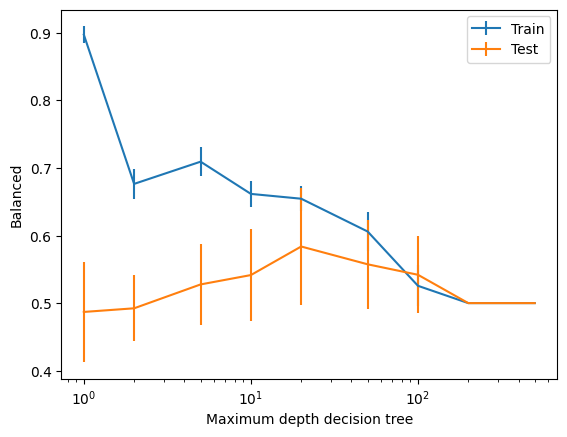

In [27]:
pipe2 = make_pipeline(StandardScaler(), KNeighborsClassifier())
print(pipe2.get_params())
neighbours_param = np.array([1, 2, 5, 10, 20, 50, 100, 200, 500])
valcurve = ValidationCurveDisplay.from_estimator(pipe2, features, target, cv=5, param_name="kneighborsclassifier__n_neighbors",
                                                 param_range=neighbours_param, scoring='balanced_accuracy',
                                                 negate_score=False, std_display_style="errorbar", n_jobs=2)
valcurve.ax_.set(xlabel="Maximum depth decision tree", ylabel="Balanced")

How to get the parameters in a pipe.

In [28]:
pipe2 = make_pipeline(StandardScaler(), KNeighborsClassifier())
print(pipe2.get_params())

{'memory': None, 'steps': [('standardscaler', StandardScaler()), ('kneighborsclassifier', KNeighborsClassifier())], 'transform_input': None, 'verbose': False, 'standardscaler': StandardScaler(), 'kneighborsclassifier': KNeighborsClassifier(), 'standardscaler__copy': True, 'standardscaler__with_mean': True, 'standardscaler__with_std': True, 'kneighborsclassifier__algorithm': 'auto', 'kneighborsclassifier__leaf_size': 30, 'kneighborsclassifier__metric': 'minkowski', 'kneighborsclassifier__metric_params': None, 'kneighborsclassifier__n_jobs': None, 'kneighborsclassifier__n_neighbors': 5, 'kneighborsclassifier__p': 2, 'kneighborsclassifier__weights': 'uniform'}
